paths

In [49]:
from pathlib import Path

# Base directory for all data
path_to_notebook = Path(r"C:\Users\Nima\Desktop\test\data")

# Specific data paths (all relative to path_to_notebook)
particle_data_path = path_to_notebook / "particleData"
sun_position_path   = path_to_notebook / "Sun_position"
v_circ_path         = path_to_notebook
dm_mass_path        = path_to_notebook / "dm_mass"


formulae

In [50]:
import numpy as np

# ─── 1. Cartesian → Spherical velocities ────────────────────────────────────────
def v_r(x, y, z, vx, vy, vz):
    """Radial velocity."""
    r = np.sqrt(x**2 + y**2 + z**2)
    return (x/r)*vx + (y/r)*vy + (z/r)*vz

def v_theta(x, y, z, vx, vy, vz):
    """Polar (θ) velocity."""
    r   = np.sqrt(x**2 + y**2 + z**2)
    rho = np.sqrt(x**2 + y**2)
    return (z*x/(r*rho))*vx + (z*y/(r*rho))*vy - (rho/r)*vz

def v_phi(x, y, z, vx, vy, vz):
    """Azimuthal (φ) velocity."""
    rho = np.sqrt(x**2 + y**2)
    return -(y/rho)*vx + (x/rho)*vy


# ─── 2. Detector frame ─────────────────────────────────────────────────────────
def lambda_sun(t):
    return 2*np.pi*(t - 0.218)

def v_ex(t):
    lam = lambda_sun(t)
    return 11.1 + 29.8*(-0.067*np.sin(lam) + 0.9931*np.cos(lam))

def v_ey(t, vc):
    lam = lambda_sun(t)
    return vc + 12.24 + 29.8*(0.4927*np.sin(lam) + 0.1170*np.cos(lam))

def v_ez(t):
    lam = lambda_sun(t)
    return 7.25 + 29.8*(-0.8676*np.sin(lam) - 0.01032*np.cos(lam))

def v_e(t, vc):
    return np.sqrt(v_ex(t)**2 + v_ey(t, vc)**2 + v_ez(t)**2)


# ─── 3. Lab frame w.r.t. galactic center ────────────────────────────────────────
def v_lab_x(t):
    return -v_ex(t)

def v_lab_y(t, vc):
    return v_ey(t, vc)

def v_lab_z(t):
    return -v_ez(t)

def v_lab_x_phi(t, vc, phi):
    return -np.cos(phi)*v_ex(t) - np.sin(phi)*v_ey(t, vc)

def v_lab_y_phi(t, vc, phi):
    return -np.sin(phi)*v_ex(t) + np.cos(phi)*v_ey(t, vc)

def v_lab_z_phi(t):
    return -v_ez(t)


# ─── 4. DM particles w.r.t. Lab frame ──────────────────────────────────────────
def v_lx(u_gx, t):
    return u_gx - v_lab_x(t)

def v_ly(u_gy, t, vc):
    return u_gy - v_lab_y(t, vc)

def v_lz(u_gz, t):
    return u_gz - v_lab_z(t)

def v_lx_phi(u_gx, t, vc, phi):
    return u_gx - v_lab_x_phi(t, vc, phi)

def v_ly_phi(u_gy, t, vc, phi):
    return u_gy - v_lab_y_phi(t, vc, phi)

def v_lz_phi(u_gz, t):
    return u_gz - v_lab_z_phi(t)


# ─── 5. Marius’s galactic‐sun frame ─────────────────────────────────────────────
def v_ex_g(t):
    lam = lambda_sun(t)
    return 11.1 + 29.8*(-0.067*np.sin(lam) + 0.9931*np.cos(lam))

def v_ey_g(t, vc):
    lam = lambda_sun(t)
    return vc + 12.24 + 29.8*(0.4927*np.sin(lam) + 0.1170*np.cos(lam))

def v_ez_g(t):
    lam = lambda_sun(t)
    return 7.25 + 29.8*(-0.8676*np.sin(lam) - 0.01032*np.cos(lam))

def v_e_g(t, vc):
    return np.sqrt(v_ex_g(t)**2 + v_ey_g(t, vc)**2 + v_ez_g(t)**2)

def v_ex_m(t, vc, x1, y1, z1):
    return v_ex_g(t)*x1 + v_ey_g(t, vc)*y1 + v_ez_g(t)*z1

def v_ey_m(t, vc, x2, y2, z2):
    return v_ex_g(t)*x2 + v_ey_g(t, vc)*y2 + v_ez_g(t)*z2

def v_ez_m(t, vc, x3, y3, z3):
    return v_ex_g(t)*x3 + v_ey_g(t, vc)*y3 + v_ez_g(t)*z3

def v_lx_m(u_gx, t, vc, x1, y1, z1):
    return u_gx - v_ex_m(t, vc, x1, y1, z1)

def v_ly_m(u_gy, t, vc, x2, y2, z2):
    return u_gy - v_ey_m(t, vc, x2, y2, z2)

def v_lz_m(u_gz, t, vc, x3, y3, z3):
    return u_gz - v_ez_m(t, vc, x3, y3, z3)


# ─── 6. Anisotropy parameter β ─────────────────────────────────────────────────
def anisotropy(dataset):
    """
    dataset: np.ndarray of shape (n, m)
      columns 11→vr, 12→vth, 13→vphi (0-based indexing).
    """
    vr   = dataset[:, 11]
    vth  = dataset[:, 12]
    vphi = dataset[:, 13]
    σ_vr   = np.std(vr,   ddof=1)
    σ_vth  = np.std(vth,  ddof=1)
    σ_vphi = np.std(vphi, ddof=1)
    return 1 - (σ_vth**2 + σ_vphi**2) / (2 * σ_vr**2)


# ─── 7. Escape velocity v_esc ──────────────────────────────────────────────────
def v_escape(dataset, factor):
    """
    dataset: np.ndarray of shape (n, m)
      columns 3–5 are the velocity components (0-based).
    """
    vels  = dataset[:, 3:6] * factor
    norms = np.linalg.norm(vels, axis=1)
    return np.max(norms)


Load data

In [51]:
!pip install h5py
import h5py
import numpy as np

def get_lmc_data_hdf5(hdf5_filename):
    """
    Load LMC dark matter data from an HDF5 file.

    Parameters
    ----------
    hdf5_filename : str or Path
        Path to the HDF5 file.

    Returns
    -------
    dm_pos : np.ndarray
        Array of particle coordinates.
    dm_vel : np.ndarray
        Array of particle velocities.
    dm_tag : np.ndarray
        Array of original particle tags.
    """
    with h5py.File(hdf5_filename, "r") as f:
        dm_pos = f["Coordinates"][()]
        dm_vel = f["Velocities"][()]
        dm_tag = f["LMC_tag"][()]
    return dm_pos, dm_vel, dm_tag



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data construction

In [53]:
import numpy as np
import pandas as pd

# ─── Data construction ──────────────────────────────────────────────────────────
def build_dataset(coordinates, velocities, lmc_tag):
    """
    Construct a DataFrame combining positions, velocities, tags, radial filters, and spherical velocities.

    Parameters
    ----------
    coordinates : array-like, shape (N, 3)
        x, y, z positions.
    velocities : array-like, shape (N, 3)
        vx, vy, vz velocities.
    lmc_tag : array-like, shape (N,)
        Original LMC tags (-1 indicates MW).

    Returns
    -------
    df : pandas.DataFrame
        Columns:
        - x, y, z
        - vx, vy, vz
        - lmc_tag
        - mw_lmc
        - r_pos
        - r_6_10
        - r_7_9
        - v_r, v_theta, v_phi
    """
    coords     = np.asarray(coordinates)
    velos      = np.asarray(velocities)
    tags       = np.asarray(lmc_tag)

    x, y, z    = coords.T
    vx, vy, vz = velos.T

    # Tag classification
    mw_lmc     = np.where(tags == -1, 'mw', 'lmc')

    # Radial distances and filters
    r_pos      = np.linalg.norm(coords, axis=1)
    r_6_10     = ((r_pos >= 6.0) & (r_pos <= 10.0)).astype(int)
    r_7_9      = ((r_pos >= 7.0) & (r_pos <= 9.0)).astype(int)

    # Spherical velocities (using previously defined v_r, v_theta, v_phi)
    vr         = v_r(x, y, z, vx, vy, vz)
    v_theta_s  = v_theta(x, y, z, vx, vy, vz)
    v_phi_s    = v_phi(x, y, z, vx, vy, vz)

    # Assemble DataFrame
    df = pd.DataFrame({
        'x'      : x,
        'y'      : y,
        'z'      : z,
        'vx'     : vx,
        'vy'     : vy,
        'vz'     : vz,
        'lmc_tag': tags,
        'mw_lmc' : mw_lmc,
        'r_pos'  : r_pos,
        'r_6_10' : r_6_10,
        'r_7_9'  : r_7_9,
        'v_r'    : vr,
        'v_theta': v_theta_s,
        'v_phi'  : v_phi_s,
    })

    return df


Build a DataSet

In [54]:
def load_dataset(hdf5_filename):
    """
    Load raw LMC data from an HDF5 file and build the full dataset.

    Parameters
    ----------
    hdf5_filename : str or Path
        Path to the HDF5 file containing LMC data.

    Returns
    -------
    df : pandas.DataFrame
        Combined dataset with positions, velocities, tags, radial filters, and spherical velocities.
    """
    # Import raw data
    dm_pos, dm_vel, dm_tag = get_lmc_data_hdf5(hdf5_filename)

    # Build and return the dataset
    return build_dataset(dm_pos, dm_vel, dm_tag)


In [55]:
filename = r"C:\Users\Nima\Desktop\test\data\particleData\particleData_pair_49_snap_139.hdf5"
data = load_dataset(filename)
data

,x,y,z,vx,vy,vz,lmc_tag,mw_lmc,r_pos,r_6_10,r_7_9,v_r,v_theta,v_phi
0,-0.178008,-0.073146,0.021227,113.744072,52.729206,-26.897217,-1.000000,mw,0.193618,0,0,-127.443137,13.003402,-5.540920
1,-0.060236,-0.152928,-0.014963,68.800728,2.488624,-16.545507,-1.000000,mw,0.165043,0,0,-25.916051,18.973246,63.101992
2,0.009542,0.174691,-0.107407,81.813087,56.085884,-53.925041,-1.000000,mw,0.205291,0,0,79.742026,14.320790,-78.632321
3,0.202560,-0.317608,-0.108207,96.663422,38.817028,-44.006439,-1.000000,mw,0.391936,0,0,30.651250,36.981491,102.371947
4,0.056549,-0.057645,-0.095360,88.158340,-6.832232,-67.660805,-1.000000,mw,0.124957,0,0,94.682605,-7.111097,58.148031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238011,-7.116204,-8.110347,-9.848745,539.259888,129.924973,-173.465683,0.315702,lmc,14.608760,0,0,-217.869328,433.732986,319.657193
238012,-4.009159,-11.191335,-9.138623,513.461792,210.117920,-316.606323,-1.000000,mw,14.994458,0,0,-101.150979,477.105104,412.518261
238013,-1.315522,3.236037,-6.253296,388.444885,-17.337557,-487.723816,-1.000000,mw,7.162838,1,1,346.618040,379.587946,-353.317797
238014,-3.983718,-2.837483,-9.484252,585.623779,143.604233,-78.629196,0.713585,lmc,10.671099,0,0,-186.925007,534.028769,222.782972


The data cuts

In [56]:
def cut_dataset(data_matrix, particle_type, shell):
    """
    Filter the dataset by particle type and radial shell.

    Parameters
    ----------
    data_matrix : pandas.DataFrame
        The full dataset produced by `build_dataset`, with columns:
        - 'r_pos', 'r_6_10', 'r_7_9', 'mw_lmc', etc.
    particle_type : str
        One of 'dm', 'mw', or 'lmc'.
    shell : str or sequence of two floats
        If str, must be '6to10' or '7to9', selecting the precomputed shell flags.
        If sequence (Rmin, Rmax), selects rows with Rmin <= r_pos <= Rmax.

    Returns
    -------
    pandas.DataFrame
        The filtered subset of `data_matrix`.
    """
    import numpy as np

    # Validate particle_type
    if particle_type not in ('dm', 'mw', 'lmc'):
        raise ValueError('particle_type must be "dm", "mw", or "lmc"')

    df = data_matrix.copy()

    # Build the shell mask
    if isinstance(shell, str):
        if shell not in ('6to10', '7to9'):
            raise ValueError('If shell is a string, it must be "6to10" or "7to9"')
        col = 'r_6_10' if shell == '6to10' else 'r_7_9'
        mask = df[col] == 1

    elif (isinstance(shell, (list, tuple, np.ndarray))
          and len(shell) == 2):
        Rmin, Rmax = shell
        if not (0 <= Rmin < Rmax <= 15):
            raise ValueError(
                'For a numeric shell, provide [Rmin, Rmax] with '
                '0 ≤ Rmin < Rmax ≤ 15'
            )
        mask = df['r_pos'].between(Rmin, Rmax)

    else:
        raise ValueError(
            'shell must be either a string ("6to10"/"7to9") '
            'or a two‐element sequence [Rmin, Rmax]'
        )

    # Apply particle_type filter
    if particle_type != 'dm':
        mask &= (df['mw_lmc'] == particle_type)

    return df.loc[mask]


In [57]:
dmcutMatrix = cut_dataset(data, 'dm', '6to10')
mwcutMatrix = cut_dataset(data, 'mw', '6to10')
lmccutMatrix = cut_dataset(data, 'lmc', '6to10')

Loading Circular Velocities File based on sequence filenames

In [68]:
import numpy as np
import re
from pathlib import Path

# def name_num(filename):
#     """
#     Extract the 1- or 2-digit system number (and optional snapshot) from a filename.
    
#     Returns
#     -------
#     str or tuple(str, str) or None
#         - If only a system number is found, returns it as a string.
#         - If a snapshot is embedded, returns (system_number, snapshot).
#         - Returns None if no match.
#     """
#     # Work with the base name only
#     name = Path(filename).name
#     n = len(name)

#     if n == 23:
#         # 1-digit system, e.g. "..._N_xxx"
#         return name[17]
#     elif n == 24:
#         # 2-digit system
#         return name[17:19]
#     elif n == 33:
#         # 1-digit system + 3-char snapshot
#         system = name[18]
#         snap   = name[25:28]
#         return system, snap
#     elif n == 34:
#         # 2-digit system + 3-char snapshot
#         system = name[18:20]
#         snap   = name[27:30]
#         return system, snap
#     else:
#         # Could not match known patterns
#         return None

def name_num(filename):
    """
    Extract system and snapshot IDs from filenames like:
      '..._pair_{system}_snap_{snap}.hdf5'
    Returns
    -------
    tuple(str, str)
        (system_id, snapshot_id)
    or
    str
        If only a single ID is found.
    """
    name = Path(filename).stem  # e.g., 'particleData_pair_49_snap_139'
    # Match patterns 'pair_{system}_snap_{snap}'
    m = re.search(r'pair_(\d+)_snap_(\d+)', name)
    if m:
        return m.group(1), m.group(2)
    # Fallback: first sequence of digits
    m2 = re.search(r'(\d+)', name)
    if m2:
        return m2.group(1)
    return None


# ─── Load circular‐velocity data once ───────────────────────────────────────────
# Assumes v_circ_path is already defined as a Path to the directory containing "data_Vcirc_Sun.txt"
vc_data = np.loadtxt(v_circ_path / "data_Vcirc_Sun.txt")
# Rows 10..74 in Mathematica (1-based) → Python indices 9:74
vc_list = vc_data[9:74, [0, 2]]  # columns: [system_id, vc_value]
vc_map  = {int(row[0]): row[1] for row in vc_list}


def vc_system(filename):
    """
    Given a filename, return the local circular speed for that system.

    Parameters
    ----------
    filename : str or Path
        Path or name of the file whose system ID we extract.

    Returns
    -------
    float
        Circular speed v_c for that system.

    Raises
    ------
    ValueError
        If the system ID cannot be parsed.
    KeyError
        If the parsed system ID is not found in the circular‐velocity table.
    """
    parsed = name_num(filename)
    if isinstance(parsed, tuple):
        system_id = int(parsed[0])
    elif isinstance(parsed, str):
        system_id = int(parsed)
    else:
        raise ValueError(f"Cannot parse system ID from filename: {filename!s}")

    try:
        return vc_map[system_id]
    except KeyError:
        raise KeyError(f"System ID {system_id} not found in v_circ data")


In [69]:
vc = vc_system(filename)

In [70]:
import numpy as np
import pandas as pd
from pathlib import Path

# ─── Configure this to point at your Sun position directory ───────────────────
sun_position_path = path_to_notebook / "Sun_position"

# ─── 1. Locate the Sun‐position files ──────────────────────────────────────────
# ─── Corrected: Sun position file locator ─────────────────────────────────────
def get_sun_position_location():
    """
    Return the directory containing Sun_LMC_*.txt.
    Checks for a non-None global `snapshot_path`, else uses `sun_position_path`.
    """
    if 'snapshot_path' in globals() and snapshot_path:
        return Path(snapshot_path)
    return Path(sun_position_path)

# ─── 2. Extract Sun position closest to fixed cosines ─────────────────────────
def sun_position(filename):
    """
    Return the 9‐element Sun position and its index in the file
    that best matches cos_sv_lr = -0.835 and cos_sv_lv = -0.709.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    cos_lv = data[:, 10]
    target_lr, target_lv = -0.835, -0.709

    idx = int(np.argmin((cos_lr - target_lr)**2 + (cos_lv - target_lv)**2))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 3. Best‐fit Sun position for arbitrary cosines ────────────────────────────
def best_fit_sun_position(filename, cos_sv_lr, cos_sv_lv):
    """
    Given desired cos_sv_lr and cos_sv_lv, return the best‐matching
    (cos_lr, cos_lv) pair and its row index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    cos_lv = data[:, 10]
    diffs = (cos_lr - cos_sv_lr)**2 + (cos_lv - cos_sv_lv)**2

    idx = int(np.argmin(diffs))
    best_cosines = data[idx, 9:11]
    return best_cosines, idx

# ─── 4. Retrieve all Sun positions and cosines ────────────────────────────────
def all_sun_positions(filename):
    """
    Return list of all 9‐element positions and array of all (cos_lr, cos_lv).
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    positions = [row[:9] for row in data]
    cos_table = data[:, 9:11]
    return positions, cos_table

# ─── 5. Minimize |sv_lr - const| ───────────────────────────────────────────────
def sun_sv_lr_min_position(filename):
    """
    Return the position minimizing |cos_sv_lr + 0.835| and its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    diffs = np.abs(cos_lr + 0.835)
    idx = int(np.argmin(diffs))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 6. Minimize |sv_lv - const| ───────────────────────────────────────────────
def sun_sv_lv_min_position(filename):
    """
    Return the position minimizing |cos_sv_lv + 0.709| and its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lv = data[:, 10]
    diffs = np.abs(cos_lv + 0.709)
    idx = int(np.argmin(diffs))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 7. Random Sun position selection ───────────────────────────────────────────
def random_sun_position(filename):
    """
    Pick a random Sun position and return it with its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    idx = int(np.random.randint(0, len(data)))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 8. Interactive choice of Sun position ─────────────────────────────────────
def choose_sun_position(filename):
    """
    Prompt user to choose a row index to select Sun position.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    max_idx = len(data) - 1
    idx = int(input(f"Enter an index between 0 and {max_idx}: "))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 9. Direct index selection ─────────────────────────────────────────────────
def choose_sun_position_num(filename, idx):
    """
    Return the Sun position at the specified index without prompting.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    sun_pos = data[idx, :9]
    return sun_pos, idx


In [73]:
sunPos, row = sun_position(filename)

C:\Users\Nima\AppData\Local\Temp\ipykernel_548\3493127806.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Dot‐product cuts for the cone

In [72]:
import numpy as np
import pandas as pd

# ─── 1. Dot‐product cut for a fixed φ ───────────────────────────────────────────
def dot_product_cut(df: pd.DataFrame, phi: float) -> pd.DataFrame:
    """
    Select rows where the dot product of (x, y) with the direction φ
    exceeds the cone cosine threshold (π/4).

    Parameters
    ----------
    df  : DataFrame
        Must contain columns 'x', 'y', and 'r_pos'.
    phi : float
        Azimuthal angle in radians.

    Returns
    -------
    DataFrame
        Subset of df passing the dot‐product cut.
    """
    cos_alpha_cone = np.cos(np.pi / 4)
    cos_alpha = (df['x'] * np.cos(phi) +
                 df['y'] * np.sin(phi)) / df['r_pos']
    mask = cos_alpha >= cos_alpha_cone
    return df.loc[mask]


# ─── 2. Dot‐product cut using a given Sun‐position vector ───────────────────────
def dot_product_sun_position(df: pd.DataFrame, sun_pos: np.ndarray) -> pd.DataFrame:
    """
    Select rows where the dot product of (x, y, z) with the Sun‐position vector
    (negated) exceeds the cone cosine threshold (π/4).

    Parameters
    ----------
    df      : DataFrame
        Must contain columns 'x', 'y', 'z', and 'r_pos'.
    sun_pos : array‐like of length 3
        Sun position [x1, x2, x3].

    Returns
    -------
    DataFrame
        Subset of df passing the dot‐product cut with the Sun‐position vector.
    """
    x1, x2, x3 = sun_pos[:3]
    cos_alpha_cone = np.cos(np.pi / 4)
    cos_alpha = -(x1 * df['x'] +
                  x2 * df['y'] +
                  x3 * df['z']) / df['r_pos']
    mask = cos_alpha >= cos_alpha_cone
    return df.loc[mask]

# Example usage:
# df_cut = dot_product_cut(data_frame, phi_s)
# df_sun = dot_product_sun_position(data_frame, sun_position_array)


In [76]:
dmsun = dot_product_sun_position(dmcutMatrix, sunPos)
mwsun = dot_product_sun_position(mwcutMatrix, sunPos)
lmcsun = dot_product_sun_position(lmccutMatrix, sunPos)

3D transformation to detector reference frame

In [77]:
import numpy as np
from pathlib import Path

def lab_frame_marius(data_matrix, vc, sun_pos):
    """
    Compute lab-frame (Marius) velocities for 12 detector rotations.

    Parameters
    ----------
    data_matrix : pandas.DataFrame
        Must contain columns 'vx', 'vy', 'vz' for particle velocities.
    vc : float
        Local circular speed parameter.
    sun_pos : array-like of length 9
        Sun-position matrix entries [x1, x2, x3, y1, y2, y3, z1, z2, z3].

    Returns
    -------
    vx_lab_list, vy_lab_list, vz_lab_list : list of np.ndarray
        Each list has 12 arrays (one per rotation) of shape (N,),
        giving the transformed lab-frame velocities.
    """
    # Extract velocities as an (N,3) array
    vel = data_matrix[['vx', 'vy', 'vz']].to_numpy()

    # Unpack the Sun-position basis matrix
    x1, x2, x3 = sun_pos[0:3]
    y1, y2, y3 = sun_pos[3:6]
    z1, z2, z3 = sun_pos[6:9]

    # 12 evenly spaced rotation times (fractions of a full rotation)
    times = np.arange(12) / 12.0

    vx_lab_list = []
    vy_lab_list = []
    vz_lab_list = []

    for t in times:
        # Marius‐frame velocity components
        v_exm = v_ex_g(t) * x1 + v_ey_g(t, vc) * y1 + v_ez_g(t) * z1
        v_eym = v_ex_g(t) * x2 + v_ey_g(t, vc) * y2 + v_ez_g(t) * z2
        v_ezm = v_ex_g(t) * x3 + v_ey_g(t, vc) * y3 + v_ez_g(t) * z3

        # Lab‐frame velocities = Galactic velocities minus Sun motion
        vx_lab_list.append(vel[:, 0] - v_exm)
        vy_lab_list.append(vel[:, 1] - v_eym)
        vz_lab_list.append(vel[:, 2] - v_ezm)

    return vx_lab_list, vy_lab_list, vz_lab_list


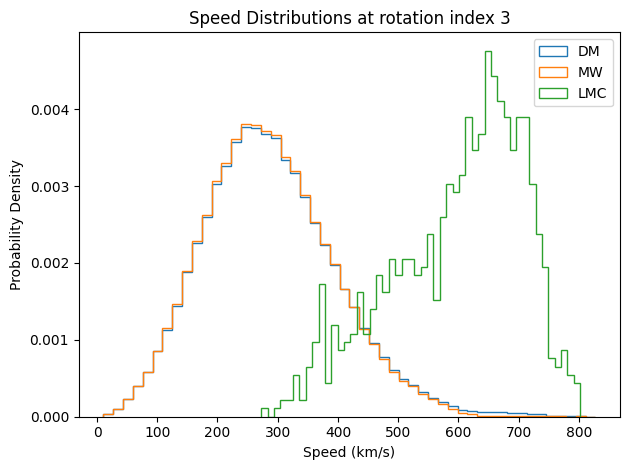

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─── 1. Build the three subsets (6–10 kpc shell) ──────────────────────────────
dmsun  = cut_dataset(df, 'dm',  [6,10])
mwsun  = cut_dataset(df, 'mw',  [6,10])
lmcsun = cut_dataset(df, 'lmc', [6,10])

# ─── 2. Compute lab‐frame velocities for each population ───────────────────────
dmvDet  = lab_frame_marius(dmsun,  vc, sunPos)
mwvDet  = lab_frame_marius(mwsun,  vc, sunPos)
lmcvDet = lab_frame_marius(lmcsun, vc, sunPos)

# Unpack into lists of 12 rotations
dm_vx,  dm_vy,  dm_vz  = dmvDet
mw_vx,  mw_vy,  mw_vz  = mwvDet
lmc_vx, lmc_vy, lmc_vz = lmcvDet

# ─── 3. Pick a rotation index (0…11) ───────────────────────────────────────────
time_idx = 0

# ─── 4. Compute speed arrays ───────────────────────────────────────────────────
speeds_dm  = np.sqrt(dm_vx[time_idx]**2  + dm_vy[time_idx]**2  + dm_vz[time_idx]**2)
speeds_mw  = np.sqrt(mw_vx[time_idx]**2  + mw_vy[time_idx]**2  + mw_vz[time_idx]**2)
speeds_lmc = np.sqrt(lmc_vx[time_idx]**2 + lmc_vy[time_idx]**2 + lmc_vz[time_idx]**2)

# ─── 5. Plot all three on one figure ───────────────────────────────────────────
plt.figure()
plt.hist(speeds_dm,  bins=50, density=True, histtype='step', label='DM')
plt.hist(speeds_mw,  bins=50, density=True, histtype='step', label='MW')
plt.hist(speeds_lmc, bins=50, density=True, histtype='step', label='LMC')

plt.xlabel('Speed (km/s)')
plt.ylabel('Probability Density')
plt.title(f'Speed Distributions at rotation index {time_idx}')
plt.legend()
plt.tight_layout()
plt.show()


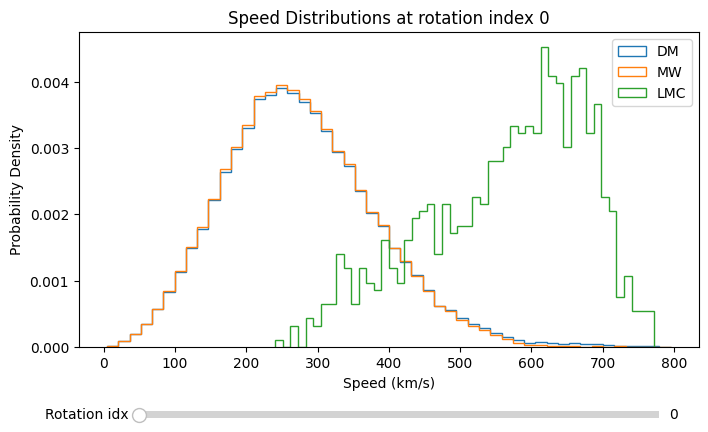

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ─── 1. Build the three subsets (6–10 kpc shell) ──────────────────────────────
dmsun  = cut_dataset(df, 'dm',  [6,10])
mwsun  = cut_dataset(df, 'mw',  [6,10])
lmcsun = cut_dataset(df, 'lmc', [6,10])

# ─── 2. Compute lab‐frame velocities for each population ───────────────────────
dmvDet  = lab_frame_marius(dmsun,  vc, sunPos)
mwvDet  = lab_frame_marius(mwsun,  vc, sunPos)
lmcvDet = lab_frame_marius(lmcsun, vc, sunPos)

# Unpack into lists of 12 rotations
dm_vx,  dm_vy,  dm_vz  = dmvDet
mw_vx,  mw_vy,  mw_vz  = mwvDet
lmc_vx, lmc_vy, lmc_vz = lmcvDet

# ─── Initial speed arrays for index 0 ─────────────────────────────────────────
def compute_speeds(idx):
    return (
        np.sqrt(dm_vx[idx]**2 + dm_vy[idx]**2 + dm_vz[idx]**2),
        np.sqrt(mw_vx[idx]**2 + mw_vy[idx]**2 + mw_vz[idx]**2),
        np.sqrt(lmc_vx[idx]**2 + lmc_vy[idx]**2 + lmc_vz[idx]**2)
    )

speeds_dm, speeds_mw, speeds_lmc = compute_speeds(0)

# ─── Setup plot and slider ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
plt.subplots_adjust(bottom=0.25)

# Initial histograms
hist_dm = ax.hist(speeds_dm,  bins=50, density=True, histtype='step', label='DM')
hist_mw = ax.hist(speeds_mw,  bins=50, density=True, histtype='step', label='MW')
hist_lmc= ax.hist(speeds_lmc, bins=50, density=True, histtype='step', label='LMC')

ax.set_xlabel('Speed (km/s)')
ax.set_ylabel('Probability Density')
ax.set_title('Speed Distributions at rotation index 0')
ax.legend()

# Slider axis
slider_ax = fig.add_axes([0.2, 0.1, 0.65, 0.03])
slider = Slider(
    ax=slider_ax,
    label='Rotation idx',
    valmin=0,
    valmax=11,
    valinit=0,
    valstep=1
)

# Update function
def update(val):
    idx = int(slider.val)
    ax.clear()
    speeds_dm, speeds_mw, speeds_lmc = compute_speeds(idx)
    ax.hist(speeds_dm,  bins=50, density=True, histtype='step', label='DM')
    ax.hist(speeds_mw,  bins=50, density=True, histtype='step', label='MW')
    ax.hist(speeds_lmc, bins=50, density=True, histtype='step', label='LMC')
    ax.set_xlabel('Speed (km/s)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Speed Distributions at rotation index {idx}')
    ax.legend()
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

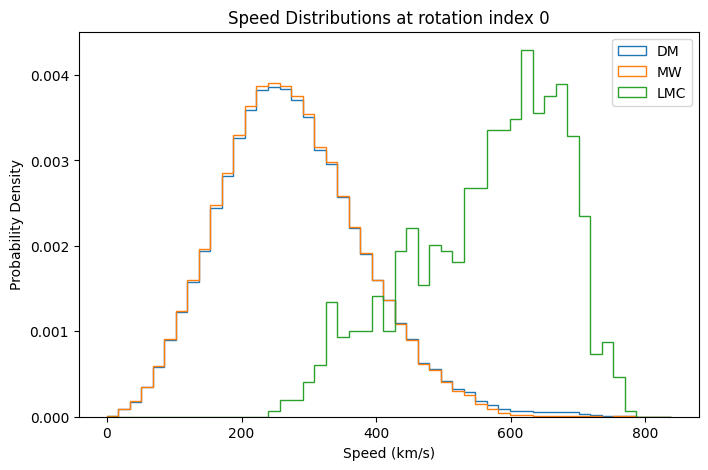

In [96]:
# Create shell subsets
dmsun  = cut_dataset(df, 'dm',  [6,10])
mwsun  = cut_dataset(df, 'mw',  [6,10])
lmcsun = cut_dataset(df, 'lmc', [6,10])

# Compute lab‐frame velocities
dmvDet  = lab_frame_marius(dmsun,  vc, sunPos)
mwvDet  = lab_frame_marius(mwsun,  vc, sunPos)
lmcvDet = lab_frame_marius(lmcsun, vc, sunPos)

dm_vx, dm_vy, dm_vz   = dmvDet
mw_vx, mw_vy, mw_vz   = mwvDet
lmc_vx, lmc_vy, lmc_vz = lmcvDet

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

# ─── Ensure you have precomputed dmvDet, mwvDet, lmcvDet via lab_frame_marius ───
# dm_vx, dm_vy, dm_vz = dmvDet
# mw_vx, mw_vy, mw_vz = mwvDet
# lmc_vx, lmc_vy, lmc_vz = lmcvDet

# Determine a common bin range across all populations and frames
all_speeds = []
for idx in range(12):
    all_speeds.extend(np.sqrt(dm_vx[idx]**2 + dm_vy[idx]**2 + dm_vz[idx]**2))
    all_speeds.extend(np.sqrt(mw_vx[idx]**2 + mw_vy[idx]**2 + mw_vz[idx]**2))
    all_speeds.extend(np.sqrt(lmc_vx[idx]**2 + lmc_vy[idx]**2 + lmc_vz[idx]**2))
max_speed = np.max(all_speeds)
bins = np.linspace(0, max_speed, 50)

# Setup figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

def animate(frame_idx):
    ax.clear()
    # Compute speeds for this rotation index
    speeds_dm  = np.sqrt(dm_vx[frame_idx]**2  + dm_vy[frame_idx]**2  + dm_vz[frame_idx]**2)
    speeds_mw  = np.sqrt(mw_vx[frame_idx]**2  + mw_vy[frame_idx]**2  + mw_vz[frame_idx]**2)
    speeds_lmc = np.sqrt(lmc_vx[frame_idx]**2 + lmc_vy[frame_idx]**2 + lmc_vz[frame_idx]**2)
    
    # Plot histograms
    ax.hist(speeds_dm,  bins=bins, density=True, histtype='step', label='DM')
    ax.hist(speeds_mw,  bins=bins, density=True, histtype='step', label='MW')
    ax.hist(speeds_lmc, bins=bins, density=True, histtype='step', label='LMC')
    
    ax.set_xlabel('Speed (km/s)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Speed Distributions at rotation index {frame_idx}')
    ax.legend(loc='upper right')

# Configure animation to render as JS HTML in Jupyter
rc('animation', html='jshtml')
anim = animation.FuncAnimation(fig, animate, frames=12, interval=500)

# Display the interactive animation
HTML(anim.to_jshtml())
